# Mango Variety Recognition (MangoClassify-12) - full pipeline
Run the cells **top to bottom**. Sections:
0. Setup and look at the data
1. Build index + resize images (cache)
2. Find near-duplicate groups (leakage protection) + train/val/test split
3. Models and training code
4. Run experiments E1-E6 (+ optional extra seeds)
5. Results tables, confusion matrices, minority-class analysis
6. Efficiency table
7. Grad-CAM


## 0. Setup and look at the data

In [1]:
import os, json, time, random, warnings
from pathlib import Path
import numpy as np, pandas as pd
warnings.filterwarnings("ignore")

INPUT = Path("/kaggle/input")
for p in sorted(INPUT.iterdir()):
    print("ATTACHED:", p)
    for sub in sorted(p.iterdir())[:20]:
        if sub.is_dir():
            n = sum(1 for f in sub.rglob("*") if f.suffix.lower() in {".jpg", ".jpeg", ".png"})
            print("    folder", sub.name, "->", n, "images")
        else:
            print("    file  ", sub.name)

ATTACHED: /kaggle/input/datasets
    folder researchersajid -> 3900 images


In [2]:
# If you attached more than one dataset, set DATA_ROOT by hand, e.g. Path("/kaggle/input/your-dataset-name")
DATA_ROOT = next(INPUT.iterdir())
print("Using:", DATA_ROOT)

WORK  = Path("/kaggle/working")
SMALL = WORK / "small"        # resized image cache
OUT   = WORK / "outputs"      # everything you want to keep
SMALL.mkdir(exist_ok=True); OUT.mkdir(exist_ok=True)

SEED = 42
IMG = 224      # training image size
CACHE = 256    # cached image size

Using: /kaggle/input/datasets


## 1. Build the image index and resize (cache)

In [3]:
exts = {".jpg", ".jpeg", ".png"}
rows = [{"src": str(p), "label": p.parent.name} for p in DATA_ROOT.rglob("*") if p.suffix.lower() in exts]
df = pd.DataFrame(rows).sort_values("src").reset_index(drop=True)
print("Total images:", len(df))
print(df.label.value_counts())
print("Number of classes:", df.label.nunique(), "(expected 12; if not, the folder structure is nested - see the guide)")
print("Sample original file names:"); print(df.src.sample(10, random_state=0).tolist())

Total images: 3900
label
Amrapali       600
Harivanga      575
Langra         506
Himsagar       502
GopalBhog      406
Khrishapat     380
Bari 4         240
Sundari        226
Banana         212
Fazli          120
RaniBhog        92
GobindoBhog     41
Name: count, dtype: int64
Number of classes: 12 (expected 12; if not, the folder structure is nested - see the guide)
Sample original file names:
['/kaggle/input/datasets/researchersajid/mangoclassify-12-native-mango-dataset-from-bd/MangoClassify-12/Harivanga/IMG_20250613_140658.jpg', '/kaggle/input/datasets/researchersajid/mangoclassify-12-native-mango-dataset-from-bd/MangoClassify-12/GopalBhog/IMG_20250601_173808.jpg', '/kaggle/input/datasets/researchersajid/mangoclassify-12-native-mango-dataset-from-bd/MangoClassify-12/Amrapali/IMG20250627180244.jpg', '/kaggle/input/datasets/researchersajid/mangoclassify-12-native-mango-dataset-from-bd/MangoClassify-12/Langra/IMG20250628181258.jpg', '/kaggle/input/datasets/researchersajid/mangoclassif

In [4]:
from PIL import Image, ImageOps
from concurrent.futures import ThreadPoolExecutor

def resize_one(args):
    i, src, label = args
    out = SMALL / label / f"{i:05d}.jpg"
    if out.exists():
        return str(out)
    out.parent.mkdir(parents=True, exist_ok=True)
    try:
        im = Image.open(src)
        im.draft("RGB", (CACHE * 2, CACHE * 2))     # fast JPEG decode at reduced size
        im = ImageOps.exif_transpose(im)             # fix phone-photo rotation
        im = im.convert("RGB").resize((CACHE, CACHE), Image.BILINEAR)
        im.save(out, quality=92)
        return str(out)
    except Exception as e:
        print("FAILED", src, e)
        return None

t0 = time.time()
jobs = [(i, r.src, r.label) for i, r in df.iterrows()]
with ThreadPoolExecutor(4) as ex:
    df["path"] = list(ex.map(resize_one, jobs))
df = df.dropna(subset=["path"]).reset_index(drop=True)
print("Done in %.1f min, images kept: %d" % ((time.time() - t0) / 60, len(df)))

Done in 2.3 min, images kept: 3900


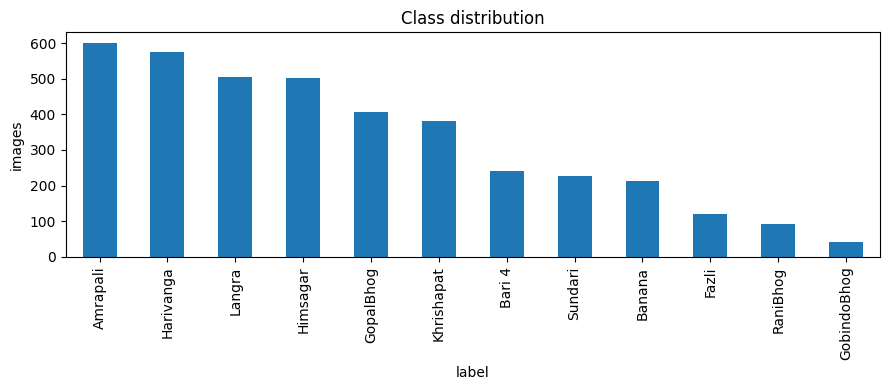

In [8]:
import matplotlib.pyplot as plt
classes = sorted(df.label.unique()); cls2idx = {c: i for i, c in enumerate(classes)}
df["y"] = df.label.map(cls2idx)
counts = df.label.value_counts().reindex(classes).sort_values(ascending=False)
plt.figure(figsize=(9, 4)); counts.plot.bar(); plt.title("Class distribution"); plt.ylabel("images"); plt.tight_layout()
plt.savefig(OUT / "class_distribution.png", dpi=150); plt.show()

## 2. Leakage protection + split
The same fruit is photographed from several angles. If those photos land in different splits, test accuracy is inflated.
We look for **near-duplicate groups** (per class) using pretrained-CNN features, then split **by group**.

In [9]:
import torch, torch.nn as nn, torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from torchvision import models, transforms

device = "cuda" if torch.cuda.is_available() else "cpu"
print("Device:", device)

def set_seed(s):
    random.seed(s); np.random.seed(s); torch.manual_seed(s); torch.cuda.manual_seed_all(s)
set_seed(SEED)

MEAN, STD = [0.485, 0.456, 0.406], [0.229, 0.224, 0.225]
norm = transforms.Normalize(MEAN, STD)
plain_tf = transforms.Compose([transforms.Resize((IMG, IMG)), transforms.ToTensor(), norm])

class ImgDS(Dataset):
    def __init__(self, paths, labels, tf):
        self.paths, self.labels, self.tf = list(paths), list(labels), tf
    def __len__(self): return len(self.paths)
    def __getitem__(self, i):
        return self.tf(Image.open(self.paths[i]).convert("RGB")), self.labels[i]

fe = models.mobilenet_v2(weights=models.MobileNet_V2_Weights.IMAGENET1K_V1)
fe.classifier = nn.Identity(); fe = fe.to(device).eval()
dl = DataLoader(ImgDS(df.path, df.y, plain_tf), batch_size=64, num_workers=2)
feats = []
with torch.no_grad():
    for x, _ in dl:
        feats.append(fe(x.to(device)).cpu().numpy())
feats = np.concatenate(feats); print("Feature matrix:", feats.shape)
del fe; torch.cuda.empty_cache()

Device: cuda
Downloading: "https://download.pytorch.org/models/mobilenet_v2-b0353104.pth" to /root/.cache/torch/hub/checkpoints/mobilenet_v2-b0353104.pth


100%|██████████| 13.6M/13.6M [00:00<00:00, 120MB/s]


Feature matrix: (3900, 1280)


In [15]:
from sklearn.cluster import AgglomerativeClustering

def cluster_all(thresh):
    g = np.full(len(df), -1); gid = 0
    for c in classes:
        idx = df.index[df.label == c].to_numpy()
        f = feats[idx]; f = f / np.linalg.norm(f, axis=1, keepdims=True)
        cl = AgglomerativeClustering(n_clusters=None, distance_threshold=thresh,
                                     metric="cosine", linkage="average").fit_predict(f)
        g[idx] = cl + gid; gid += cl.max() + 1
    return g

for t in [0.02, 0.04, 0.06, 0.08, 0.10, 0.15, 0.20]:
    s = pd.Series(cluster_all(t)).value_counts()
    print(f"thresh {t:.2f}: groups {len(s)}, largest group {s.max()} ({s.max()/len(df):.1%} of data), singletons {(s==1).sum()}")

thresh 0.02: groups 3637, largest group 5 (0.1% of data), singletons 3406
thresh 0.04: groups 3343, largest group 11 (0.3% of data), singletons 2928
thresh 0.06: groups 2505, largest group 33 (0.8% of data), singletons 1745
thresh 0.08: groups 1504, largest group 51 (1.3% of data), singletons 789
thresh 0.10: groups 848, largest group 128 (3.3% of data), singletons 336
thresh 0.15: groups 172, largest group 424 (10.9% of data), singletons 40
thresh 0.20: groups 43, largest group 591 (15.2% of data), singletons 10


In [16]:
THRESH = 0.08
df["group"] = cluster_all(THRESH)
sizes = df.group.value_counts()
print("Images:", len(df), "| groups:", df.group.nunique(), "| largest group:", sizes.max())

Images: 3900 | groups: 1504 | largest group: 51


In [18]:
from sklearn.model_selection import StratifiedGroupKFold

best = None
for seed in range(60):
    sg = StratifiedGroupKFold(n_splits=7, shuffle=True, random_state=seed)
    fl = [te for _, te in sg.split(df, df.y, groups=df.group)]
    sp = np.array(["train"] * len(df), dtype=object)
    sp[fl[0]] = "test"; sp[fl[1]] = "val"
    t = pd.crosstab(df.label, sp)[["train", "val", "test"]]
    frac = t[["val", "test"]].div(t.sum(1), axis=0)
    score = (frac - 1 / 7).abs().to_numpy().max()      # worst-class deviation from 14.3%
    if best is None or score < best[0]:
        best = (score, seed, sp.copy())

print("best split seed:", best[1], "| worst-class deviation:", round(best[0], 3))
df["split"] = best[2]

print(df.split.value_counts())
tab = pd.crosstab(df.label, df.split)[["train", "val", "test"]]
print(tab)

assert (df.groupby("group").split.nunique() == 1).all(), "Leakage: a group appears in more than one split"
assert (tab > 0).all().all(), "Some class is missing from a split."

df.to_csv(OUT / "splits.csv", index=False)
tab.to_csv(OUT / "split_counts_per_class.csv")

best split seed: 58 | worst-class deviation: 0.053
split
train    2779
test      571
val       550
Name: count, dtype: int64
split        train  val  test
label                        
Amrapali       410  110    80
Banana         153   26    33
Bari 4         170   39    31
Fazli           87   21    12
GobindoBhog     30    5     6
GopalBhog      279   51    76
Harivanga      437   71    67
Himsagar       360   63    79
Khrishapat     253   68    59
Langra         373   62    71
RaniBhog        63   11    18
Sundari        164   23    39


## 3. Models and training code

In [23]:
train_df = df[df.split == "train"].reset_index(drop=True)
val_df   = df[df.split == "val"].reset_index(drop=True)
test_df  = df[df.split == "test"].reset_index(drop=True)
NC = len(classes)

aug_tf = transforms.Compose([
    transforms.RandomResizedCrop(IMG, scale=(0.7, 1.0)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(15),
    transforms.ColorJitter(brightness=0.2),
    transforms.ToTensor(), norm])

class SmallCNN(nn.Module):
    def __init__(self, n):
        super().__init__()
        def blk(i, o):
            return nn.Sequential(nn.Conv2d(i, o, 3, padding=1), nn.BatchNorm2d(o), nn.ReLU(), nn.MaxPool2d(2))
        self.features = nn.Sequential(blk(3, 32), blk(32, 64), blk(64, 128), blk(128, 256))
        self.head = nn.Sequential(nn.AdaptiveAvgPool2d(1), nn.Flatten(), nn.Dropout(0.3), nn.Linear(256, n))
    def forward(self, x): return self.head(self.features(x))

def make_model(kind, n):
    if kind == "cnn":
        return SmallCNN(n)
    if kind == "resnet18":
        m = models.resnet18(weights=models.ResNet18_Weights.IMAGENET1K_V1)
        m.fc = nn.Sequential(nn.Dropout(0.3), nn.Linear(512, n)); return m
    if kind == "efficientnet":
        m = models.efficientnet_b0(weights=models.EfficientNet_B0_Weights.IMAGENET1K_V1)
        m.classifier = nn.Sequential(nn.Dropout(0.3), nn.Linear(1280, n)); return m
    m = models.mobilenet_v2(weights=models.MobileNet_V2_Weights.IMAGENET1K_V1)
    m.classifier = nn.Sequential(nn.Dropout(0.3), nn.Linear(1280, n))
    return m

def backbone_modules(model, kind):          # everything except the new classifier head
    if kind == "resnet18":
        return [model.conv1, model.bn1, model.layer1, model.layer2, model.layer3, model.layer4]
    return [model.features]

def upper_modules(model, kind):             # the part unfrozen during fine-tuning
    if kind == "mobilenet":    return list(model.features[10:])
    if kind == "efficientnet": return list(model.features[5:])
    if kind == "resnet18":     return [model.layer4]

class FocalLoss(nn.Module):
    """Focal loss (Lin et al., 2017): down-weights easy examples, focusing on hard/rare ones."""
    def __init__(self, gamma=2.0, weight=None):
        super().__init__(); self.gamma, self.weight = gamma, weight
    def forward(self, logits, y):
        logp = F.log_softmax(logits, 1)
        logpt = logp.gather(1, y[:, None])[:, 0]
        loss = -((1 - logpt.exp()) ** self.gamma) * logpt
        if self.weight is not None: loss = loss * self.weight[y]
        return loss.mean()

def class_weights(train_labels, n):
    cnt = np.bincount(train_labels, minlength=n).astype(float)
    w = 1.0 / np.sqrt(cnt)                      # square-root inverse frequency
    w = w * (cnt.sum() / (w * cnt).sum())       # keep average loss scale ~1
    return torch.tensor(w, dtype=torch.float32)

from sklearn.metrics import (accuracy_score, precision_recall_fscore_support,
                             classification_report, confusion_matrix, f1_score)

@torch.no_grad()
def predict(model, loader):
    model.eval(); P, Y = [], []
    for x, y in loader:
        P.append(F.softmax(model(x.to(device)), 1).cpu()); Y.append(y)
    P = torch.cat(P).numpy(); return P.argmax(1), P, torch.cat(Y).numpy()

In [24]:
def run_experiment(name, kind, mode, aug, cw, epochs, seed=SEED, head_epochs=3, bs=32, loss_name="ce"):
    """kind: cnn|mobilenet|resnet18|efficientnet   mode: scratch|frozen|finetune   loss_name: ce|focal"""
    res_path = OUT / f"{name}_result.json"
    if res_path.exists():
        print(f"[{name}] already done, skipping"); return json.load(open(res_path))
    print(f"\n===== {name}: {kind}/{mode} aug={aug} classweights={cw} loss={loss_name} seed={seed} =====")
    set_seed(seed)
    model = make_model(kind, NC).to(device)

    frozen_backbone = kind != "cnn" and mode in ("frozen", "finetune")
    if frozen_backbone:
        for mod in backbone_modules(model, kind):
            for p in mod.parameters(): p.requires_grad = False

    tl = DataLoader(ImgDS(train_df.path, train_df.y, aug_tf if aug else plain_tf),
                    batch_size=bs, shuffle=True, num_workers=2, pin_memory=True, drop_last=True)
    vl = DataLoader(ImgDS(val_df.path, val_df.y, plain_tf), batch_size=64, num_workers=2)
    te = DataLoader(ImgDS(test_df.path, test_df.y, plain_tf), batch_size=64, num_workers=2)

    w = class_weights(train_df.y.values, NC).to(device) if cw else None
    crit = FocalLoss(2.0, weight=w) if loss_name == "focal" else nn.CrossEntropyLoss(weight=w)
    lr = 1e-3
    def make_opt(lr): return torch.optim.Adam([p for p in model.parameters() if p.requires_grad], lr=lr)
    opt = make_opt(lr)
    scaler = torch.cuda.amp.GradScaler(enabled=(device == "cuda"))

    best_f1, hist, t0 = -1, [], time.time()
    ckpt = OUT / f"{name}.pt"
    for ep in range(epochs):
        if mode == "finetune" and ep == head_epochs:       # stage 2: unfreeze upper blocks, small LR
            for mod in upper_modules(model, kind):
                for p in mod.parameters(): p.requires_grad = True
            frozen_backbone = False
            opt = make_opt(1e-4); print("  -> unfroze upper blocks, lr=1e-4")
        model.train()
        if frozen_backbone:                                # keep BatchNorm stats fixed while frozen
            for mod in backbone_modules(model, kind): mod.eval()
        tot = 0
        for x, y in tl:
            x, y = x.to(device), y.to(device)
            opt.zero_grad()
            with torch.autocast(device_type="cuda", enabled=(device == "cuda")):
                loss = crit(model(x), y)
            scaler.scale(loss).backward(); scaler.step(opt); scaler.update()
            tot += loss.item() * len(y)
        vp, _, vy = predict(model, vl)
        vf1 = f1_score(vy, vp, average="macro"); vacc = accuracy_score(vy, vp)
        hist.append({"epoch": ep + 1, "train_loss": tot / (len(tl) * bs), "val_acc": vacc, "val_macro_f1": vf1})
        print(f"  ep {ep+1:02d} loss {hist[-1]['train_loss']:.3f} val_acc {vacc:.3f} val_macroF1 {vf1:.3f}")
        if vf1 > best_f1:
            best_f1 = vf1; torch.save(model.state_dict(), ckpt)

    model.load_state_dict(torch.load(ckpt)); tp, tprob, ty = predict(model, te)
    p, r, f, _ = precision_recall_fscore_support(ty, tp, average="macro", zero_division=0)
    res = {"name": name, "kind": kind, "mode": mode, "aug": aug, "cw": cw, "loss": loss_name, "seed": seed,
           "test_acc": accuracy_score(ty, tp), "test_macro_precision": p, "test_macro_recall": r, "test_macro_f1": f,
           "best_val_macro_f1": best_f1, "train_minutes": (time.time() - t0) / 60,
           "per_class": classification_report(ty, tp, target_names=classes, output_dict=True, zero_division=0),
           "confusion": confusion_matrix(ty, tp, labels=range(NC)).tolist(), "history": hist}
    json.dump(res, open(res_path, "w"))
    pd.DataFrame({"path": test_df.path, "true": ty, "pred": tp, "conf": tprob.max(1)}).to_csv(OUT / f"{name}_preds.csv", index=False)
    print(f"  TEST acc {res['test_acc']:.3f} | macroF1 {res['test_macro_f1']:.3f}")
    return res

## 4. Run the experiments
Each finished experiment is saved, so if you re-run the notebook it skips completed ones.

In [25]:
CNN_EPOCHS, MB_EPOCHS = 20, 12
EXPS = [  # name, kind, mode, aug, class weights, epochs
    ("E1", "cnn",       "scratch",  False, False, CNN_EPOCHS),
    ("E2", "mobilenet", "frozen",   False, False, MB_EPOCHS),
    ("E3", "mobilenet", "finetune", False, False, MB_EPOCHS),
    ("E4", "mobilenet", "finetune", True,  False, MB_EPOCHS),
    ("E5", "mobilenet", "finetune", False, True,  MB_EPOCHS),
    ("E6", "mobilenet", "finetune", True,  True,  MB_EPOCHS),
]
for e in EXPS:
    run_experiment(*e)


===== E1: cnn/scratch aug=False classweights=False loss=ce seed=42 =====
  ep 01 loss 1.550 val_acc 0.362 val_macroF1 0.338
  ep 02 loss 1.213 val_acc 0.418 val_macroF1 0.350
  ep 03 loss 1.058 val_acc 0.476 val_macroF1 0.441
  ep 04 loss 0.921 val_acc 0.605 val_macroF1 0.517
  ep 05 loss 0.835 val_acc 0.547 val_macroF1 0.506
  ep 06 loss 0.793 val_acc 0.429 val_macroF1 0.420
  ep 07 loss 0.724 val_acc 0.591 val_macroF1 0.597
  ep 08 loss 0.681 val_acc 0.635 val_macroF1 0.612
  ep 09 loss 0.634 val_acc 0.700 val_macroF1 0.637
  ep 10 loss 0.630 val_acc 0.393 val_macroF1 0.369
  ep 11 loss 0.581 val_acc 0.720 val_macroF1 0.679
  ep 12 loss 0.574 val_acc 0.687 val_macroF1 0.614
  ep 13 loss 0.561 val_acc 0.669 val_macroF1 0.621
  ep 14 loss 0.520 val_acc 0.200 val_macroF1 0.189
  ep 15 loss 0.521 val_acc 0.602 val_macroF1 0.591
  ep 16 loss 0.484 val_acc 0.767 val_macroF1 0.647
  ep 17 loss 0.458 val_acc 0.718 val_macroF1 0.655
  ep 18 loss 0.434 val_acc 0.633 val_macroF1 0.559
  ep 19 

In [26]:
# Extra seeds for the two key runs (E3 vs E6): rare-class test sets are tiny, so one run is not enough evidence
for s in (1, 2):
    run_experiment(f"E3_s{s}", "mobilenet", "finetune", False, False, MB_EPOCHS, seed=s)
    run_experiment(f"E6_s{s}", "mobilenet", "finetune", True,  True,  MB_EPOCHS, seed=s)


===== E3_s1: mobilenet/finetune aug=False classweights=False loss=ce seed=1 =====
  ep 01 loss 1.586 val_acc 0.715 val_macroF1 0.567
  ep 02 loss 0.937 val_acc 0.780 val_macroF1 0.692
  ep 03 loss 0.746 val_acc 0.813 val_macroF1 0.739
  -> unfroze upper blocks, lr=1e-4
  ep 04 loss 0.747 val_acc 0.905 val_macroF1 0.871
  ep 05 loss 0.136 val_acc 0.929 val_macroF1 0.921
  ep 06 loss 0.068 val_acc 0.933 val_macroF1 0.912
  ep 07 loss 0.032 val_acc 0.940 val_macroF1 0.920
  ep 08 loss 0.026 val_acc 0.944 val_macroF1 0.924
  ep 09 loss 0.017 val_acc 0.951 val_macroF1 0.928
  ep 10 loss 0.011 val_acc 0.958 val_macroF1 0.937
  ep 11 loss 0.008 val_acc 0.955 val_macroF1 0.929
  ep 12 loss 0.006 val_acc 0.955 val_macroF1 0.927
  TEST acc 0.972 | macroF1 0.963

===== E6_s1: mobilenet/finetune aug=True classweights=True loss=ce seed=1 =====
  ep 01 loss 1.748 val_acc 0.651 val_macroF1 0.558
  ep 02 loss 1.110 val_acc 0.644 val_macroF1 0.595
  ep 03 loss 0.913 val_acc 0.702 val_macroF1 0.663
  -

### 4b. Extensions (ablations beyond the core matrix)
- **E7**: same recipe as E6 (fine-tune + augmentation + class weights) with **ResNet18** and **EfficientNet-B0** -> does the backbone matter?
- **E8**: **focal loss** (gamma=2) instead of weighted cross-entropy -> a second imbalance-handling method to compare with E6.

In [27]:
for kind in ("resnet18", "efficientnet"):
    run_experiment(f"E7_{kind}", kind, "finetune", True, True, MB_EPOCHS)
run_experiment("E8_focal", "mobilenet", "finetune", True, False, MB_EPOCHS, loss_name="focal")


===== E7_resnet18: resnet18/finetune aug=True classweights=True loss=ce seed=42 =====
Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 168MB/s] 


  ep 01 loss 2.029 val_acc 0.467 val_macroF1 0.371
  ep 02 loss 1.484 val_acc 0.564 val_macroF1 0.479
  ep 03 loss 1.281 val_acc 0.562 val_macroF1 0.513
  -> unfroze upper blocks, lr=1e-4
  ep 04 loss 1.109 val_acc 0.740 val_macroF1 0.702
  ep 05 loss 0.460 val_acc 0.838 val_macroF1 0.825
  ep 06 loss 0.355 val_acc 0.865 val_macroF1 0.834
  ep 07 loss 0.277 val_acc 0.845 val_macroF1 0.808
  ep 08 loss 0.209 val_acc 0.905 val_macroF1 0.878
  ep 09 loss 0.160 val_acc 0.891 val_macroF1 0.868
  ep 10 loss 0.135 val_acc 0.895 val_macroF1 0.887
  ep 11 loss 0.129 val_acc 0.920 val_macroF1 0.919
  ep 12 loss 0.093 val_acc 0.922 val_macroF1 0.894
  TEST acc 0.921 | macroF1 0.903

===== E7_efficientnet: efficientnet/finetune aug=True classweights=True loss=ce seed=42 =====
Downloading: "https://download.pytorch.org/models/efficientnet_b0_rwightman-7f5810bc.pth" to /root/.cache/torch/hub/checkpoints/efficientnet_b0_rwightman-7f5810bc.pth


100%|██████████| 20.5M/20.5M [00:00<00:00, 130MB/s] 


  ep 01 loss 1.709 val_acc 0.624 val_macroF1 0.561
  ep 02 loss 1.110 val_acc 0.727 val_macroF1 0.680
  ep 03 loss 0.901 val_acc 0.782 val_macroF1 0.779
  -> unfroze upper blocks, lr=1e-4
  ep 04 loss 1.276 val_acc 0.795 val_macroF1 0.740
  ep 05 loss 0.582 val_acc 0.853 val_macroF1 0.820
  ep 06 loss 0.373 val_acc 0.882 val_macroF1 0.861
  ep 07 loss 0.278 val_acc 0.898 val_macroF1 0.865
  ep 08 loss 0.208 val_acc 0.916 val_macroF1 0.900
  ep 09 loss 0.195 val_acc 0.916 val_macroF1 0.892
  ep 10 loss 0.142 val_acc 0.947 val_macroF1 0.917
  ep 11 loss 0.141 val_acc 0.940 val_macroF1 0.919
  ep 12 loss 0.107 val_acc 0.955 val_macroF1 0.931
  TEST acc 0.963 | macroF1 0.952

===== E8_focal: mobilenet/finetune aug=True classweights=False loss=focal seed=42 =====
  ep 01 loss 1.187 val_acc 0.622 val_macroF1 0.492
  ep 02 loss 0.635 val_acc 0.693 val_macroF1 0.597
  ep 03 loss 0.533 val_acc 0.711 val_macroF1 0.630
  -> unfroze upper blocks, lr=1e-4
  ep 04 loss 0.450 val_acc 0.807 val_macroF

{'name': 'E8_focal',
 'kind': 'mobilenet',
 'mode': 'finetune',
 'aug': True,
 'cw': False,
 'loss': 'focal',
 'seed': 42,
 'test_acc': 0.9422066549912435,
 'test_macro_precision': 0.9509645680355724,
 'test_macro_recall': 0.8868013220440605,
 'test_macro_f1': 0.9120635817592282,
 'best_val_macro_f1': 0.8790087027111406,
 'train_minutes': 1.5597312490145365,
 'per_class': {'Amrapali': {'precision': 0.9743589743589743,
   'recall': 0.95,
   'f1-score': 0.9620253164556962,
   'support': 80.0},
  'Banana': {'precision': 1.0,
   'recall': 1.0,
   'f1-score': 1.0,
   'support': 33.0},
  'Bari 4': {'precision': 0.9642857142857143,
   'recall': 0.8709677419354839,
   'f1-score': 0.9152542372881356,
   'support': 31.0},
  'Fazli': {'precision': 0.875,
   'recall': 0.5833333333333334,
   'f1-score': 0.7,
   'support': 12.0},
  'GobindoBhog': {'precision': 1.0,
   'recall': 0.6666666666666666,
   'f1-score': 0.8,
   'support': 6.0},
  'GopalBhog': {'precision': 0.9615384615384616,
   'recall': 0

## 5. Results

In [28]:
import glob
R = {os.path.basename(p).replace("_result.json", ""): json.load(open(p)) for p in sorted(glob.glob(str(OUT / "*_result.json")))}
main = [k for k in ["E1", "E2", "E3", "E4", "E5", "E6"] if k in R]
tbl = pd.DataFrame([{"Exp": k, "Model": R[k]["kind"] + "/" + R[k]["mode"], "Aug": R[k]["aug"], "ClassW": R[k]["cw"],
                     "Acc": R[k]["test_acc"], "MacroP": R[k]["test_macro_precision"],
                     "MacroR": R[k]["test_macro_recall"], "MacroF1": R[k]["test_macro_f1"]} for k in main]).round(4)
print(tbl.to_string(index=False)); tbl.to_csv(OUT / "main_results.csv", index=False)

ext = [k for k in R if k.startswith("E7") or k.startswith("E8")]
if ext:
    et = pd.DataFrame([{"Exp": k, "Model": R[k]["kind"], "Loss": R[k].get("loss", "ce"), "ClassW": R[k]["cw"],
                        "Acc": R[k]["test_acc"], "MacroF1": R[k]["test_macro_f1"]} for k in ext]).round(4)
    print("\nExtensions:"); print(et.to_string(index=False)); et.to_csv(OUT / "extension_results.csv", index=False)

# mean +- std over seeds for E3 and E6 (if extra seeds were run)
for base in ("E3", "E6"):
    ks = [k for k in R if k == base or k.startswith(base + "_s")]
    if len(ks) > 1:
        f1s = [R[k]["test_macro_f1"] for k in ks]
        print(f"{base}: macro-F1 over {len(ks)} seeds = {np.mean(f1s):.3f} +- {np.std(f1s):.3f}")

Exp              Model   Aug  ClassW    Acc  MacroP  MacroR  MacroF1
 E1        cnn/scratch False   False 0.7898  0.8077  0.7808   0.7707
 E2   mobilenet/frozen False   False 0.8757  0.8783  0.8241   0.8377
 E3 mobilenet/finetune False   False 0.9702  0.9722  0.9521   0.9607
 E4 mobilenet/finetune  True   False 0.9457  0.9664  0.9040   0.9201
 E5 mobilenet/finetune False    True 0.9632  0.9500  0.9485   0.9462
 E6 mobilenet/finetune  True    True 0.9545  0.9722  0.9170   0.9300

Extensions:
            Exp        Model  Loss  ClassW    Acc  MacroF1
E7_efficientnet efficientnet    ce    True 0.9632   0.9523
    E7_resnet18     resnet18    ce    True 0.9212   0.9032
       E8_focal    mobilenet focal   False 0.9422   0.9121
E3: macro-F1 over 3 seeds = 0.962 +- 0.001
E6: macro-F1 over 3 seeds = 0.937 +- 0.011


In [29]:
# Minority-class analysis: E3 (plain) vs E6 (aug + class weights)
n_test = test_df.label.value_counts()
n_train = train_df.label.value_counts()
rows = []
for c in classes:
    rows.append({"Variety": c, "Train imgs": n_train.get(c, 0), "Test imgs": n_test.get(c, 0),
                 "Recall E3": R["E3"]["per_class"][c]["recall"], "Recall E6": R["E6"]["per_class"][c]["recall"],
                 "F1 E3": R["E3"]["per_class"][c]["f1-score"], "F1 E6": R["E6"]["per_class"][c]["f1-score"]})
pc = pd.DataFrame(rows).sort_values("Train imgs")
pc["dRecall"] = pc["Recall E6"] - pc["Recall E3"]; pc["dF1"] = pc["F1 E6"] - pc["F1 E3"]
print(pc.round(3).to_string(index=False)); pc.round(3).to_csv(OUT / "per_class_E3_vs_E6.csv", index=False)
print("NOTE: classes with few test images give very noisy recall (one image = large jump).")

    Variety  Train imgs  Test imgs  Recall E3  Recall E6  F1 E3  F1 E6  dRecall    dF1
GobindoBhog          30          6      1.000      1.000  1.000  1.000    0.000  0.000
   RaniBhog          63         18      0.944      1.000  0.971  1.000    0.056  0.029
      Fazli          87         12      0.667      0.333  0.762  0.500   -0.333 -0.262
     Banana         153         33      1.000      1.000  1.000  1.000    0.000  0.000
    Sundari         164         39      1.000      1.000  1.000  1.000    0.000  0.000
     Bari 4         170         31      0.968      0.871  0.984  0.931   -0.097 -0.053
 Khrishapat         253         59      0.966      0.949  0.950  0.966   -0.017  0.016
  GopalBhog         279         76      1.000      1.000  0.993  0.993    0.000  0.000
   Himsagar         360         79      0.962      1.000  0.968  0.952    0.038 -0.016
     Langra         373         71      0.958      0.915  0.938  0.878   -0.042 -0.060
   Amrapali         410         80      0.9

In [31]:
def pc_recall(base):
    ks = [k for k in R if k == base or k.startswith(base + "_s")]
    return pd.DataFrame({k: {c: R[k]["per_class"][c]["recall"] for c in classes} for k in ks})

r3, r6 = pc_recall("E3"), pc_recall("E6")
cmp = pd.DataFrame({"Train imgs": n_train, "Test imgs": n_test,
                    "E3 mean recall": r3.mean(1), "E6 mean recall": r6.mean(1)})
cmp["diff"] = cmp["E6 mean recall"] - cmp["E3 mean recall"]
print(cmp.sort_values("Train imgs").round(3))
print("\nFazli recall per run:"); print(r3.loc["Fazli"].round(2).to_dict(), r6.loc["Fazli"].round(2).to_dict())

             Train imgs  Test imgs  E3 mean recall  E6 mean recall   diff
GobindoBhog          30          6           1.000           1.000  0.000
RaniBhog             63         18           0.981           0.963 -0.019
Fazli                87         12           0.667           0.444 -0.222
Banana              153         33           1.000           1.000  0.000
Sundari             164         39           1.000           1.000  0.000
Bari 4              170         31           0.968           0.860 -0.108
Khrishapat          253         59           0.972           0.938 -0.034
GopalBhog           279         76           1.000           0.996 -0.004
Himsagar            360         79           0.958           0.987  0.030
Langra              373         71           0.944           0.939 -0.005
Amrapali            410         80           0.971           0.971  0.000
Harivanga           437         67           0.995           0.980 -0.015

Fazli recall per run:
{'E3': 0.67, 'E

In [32]:
for k in ["E3", "E4", "E5", "E6"]:
    print(k, "Fazli recall:", round(R[k]["per_class"]["Fazli"]["recall"], 2),
          "| Bari 4 recall:", round(R[k]["per_class"]["Bari 4"]["recall"], 2))

E3 Fazli recall: 0.67 | Bari 4 recall: 0.97
E4 Fazli recall: 0.33 | Bari 4 recall: 0.87
E5 Fazli recall: 0.67 | Bari 4 recall: 0.94
E6 Fazli recall: 0.33 | Bari 4 recall: 0.87


                                      path pred_name      conf
144  /kaggle/working/small/Fazli/01052.jpg    Langra  0.967596
145  /kaggle/working/small/Fazli/01053.jpg    Langra  0.998974
147  /kaggle/working/small/Fazli/01063.jpg    Langra  0.917874
148  /kaggle/working/small/Fazli/01064.jpg    Langra  0.965878


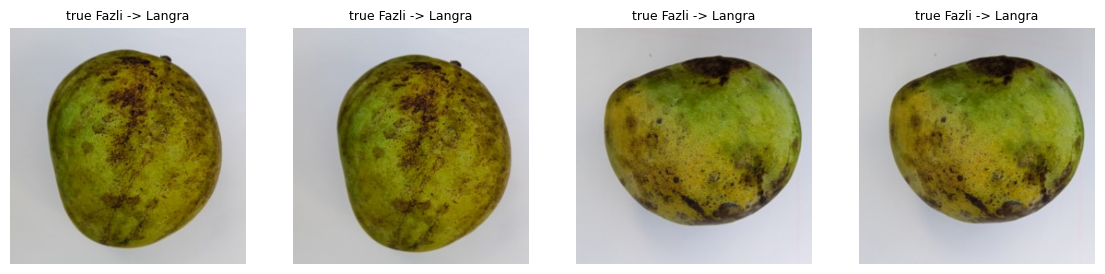

In [33]:
p = pd.read_csv(OUT / "E3_preds.csv")
fz = classes.index("Fazli")
wrong = p[(p.true == fz) & (p.pred != fz)]
print(wrong.assign(pred_name=wrong.pred.map(lambda i: classes[i]))[["path", "pred_name", "conf"]])
fig, axes = plt.subplots(1, min(4, len(wrong)), figsize=(14, 4))
for ax, (_, r) in zip(np.atleast_1d(axes), wrong.iterrows()):
    ax.imshow(Image.open(r.path)); ax.set_title("true Fazli -> " + classes[int(r.pred)], fontsize=9); ax.axis("off")
plt.show()

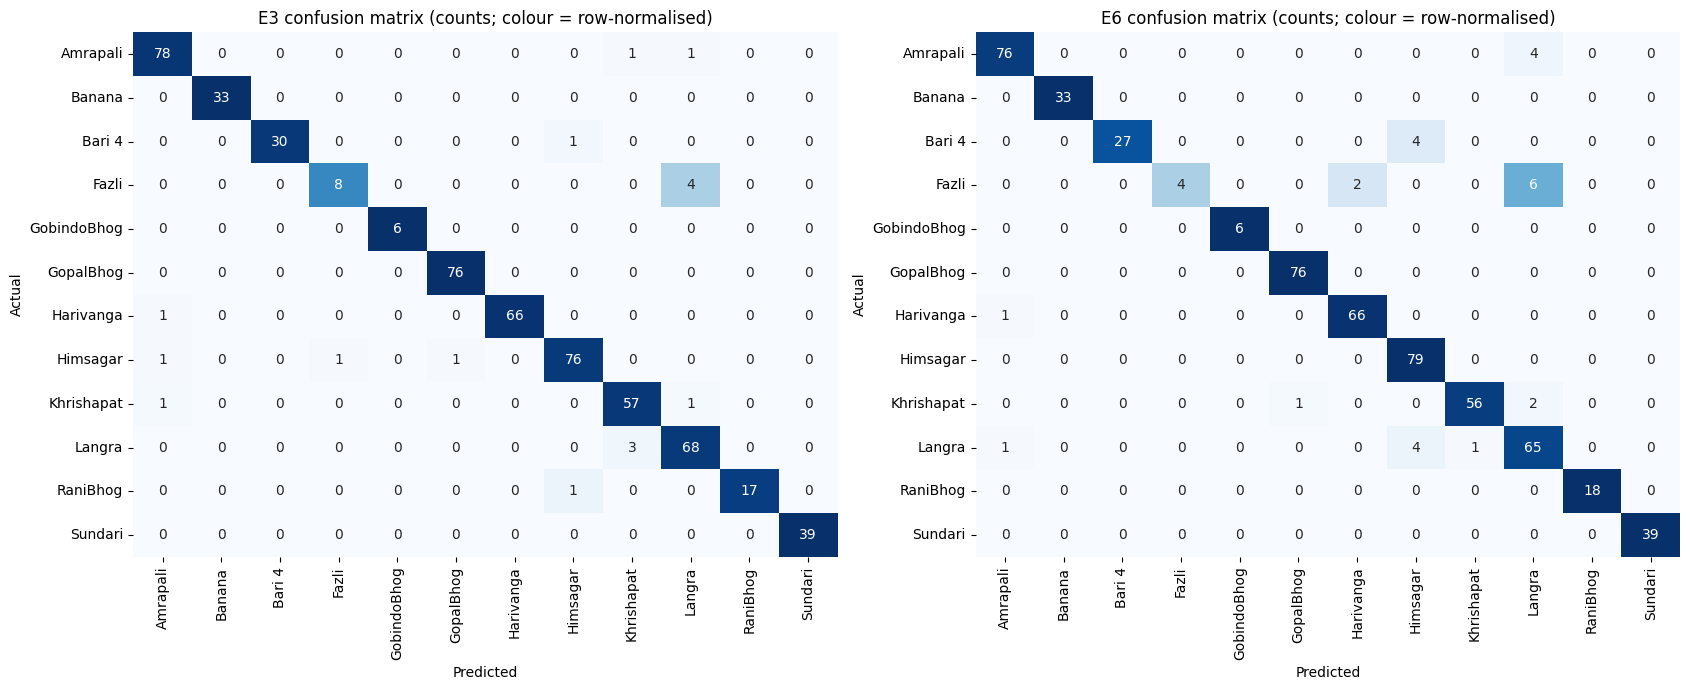

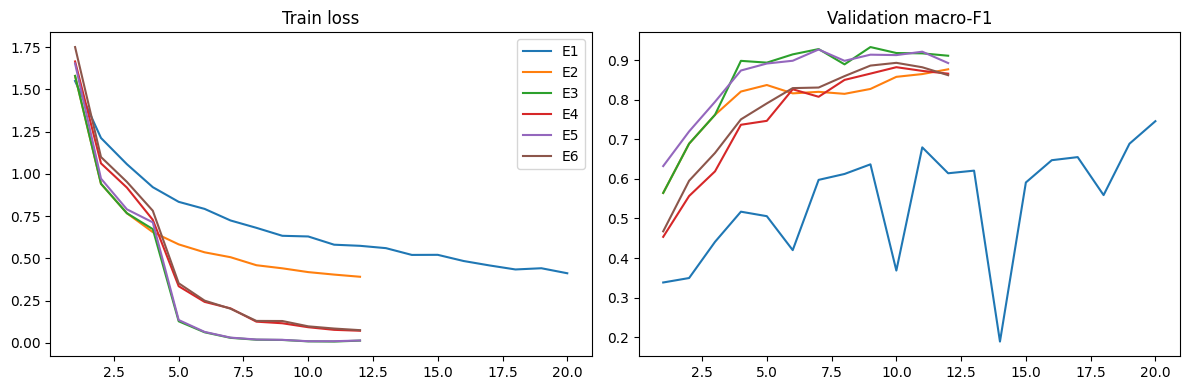

In [34]:
import seaborn as sns
fig, axes = plt.subplots(1, 2, figsize=(17, 7))
for ax, k in zip(axes, ["E3", "E6"]):
    cm = np.array(R[k]["confusion"]); cmn = cm / cm.sum(1, keepdims=True).clip(min=1)
    sns.heatmap(cmn, annot=cm, fmt="d", cmap="Blues", xticklabels=classes, yticklabels=classes, ax=ax, cbar=False)
    ax.set_title(f"{k} confusion matrix (counts; colour = row-normalised)"); ax.set_xlabel("Predicted"); ax.set_ylabel("Actual")
plt.tight_layout(); plt.savefig(OUT / "confusion_E3_E6.png", dpi=150); plt.show()

fig, ax = plt.subplots(1, 2, figsize=(12, 4))
for k in main:
    h = pd.DataFrame(R[k]["history"]); ax[0].plot(h.epoch, h.train_loss, label=k); ax[1].plot(h.epoch, h.val_macro_f1, label=k)
ax[0].set_title("Train loss"); ax[1].set_title("Validation macro-F1"); ax[0].legend(); plt.tight_layout()
plt.savefig(OUT / "training_curves.png", dpi=150); plt.show()

## 6. Efficiency (parameters, size, speed)

In [35]:
def efficiency(kind, name):
    m = make_model(kind, NC).to(device).eval()
    params = sum(p.numel() for p in m.parameters())
    size_mb = os.path.getsize(OUT / f"{name}.pt") / 1e6
    x = torch.randn(1, 3, IMG, IMG, device=device)
    with torch.no_grad():
        for _ in range(10): m(x)
        if device == "cuda": torch.cuda.synchronize()
        t = time.time()
        for _ in range(100): m(x)
        if device == "cuda": torch.cuda.synchronize()
    return {"Model": kind, "Params (M)": round(params / 1e6, 2), "Size (MB)": round(size_mb, 1),
            "ms/image (batch 1, " + device + ")": round((time.time() - t) / 100 * 1000, 2)}
eff = pd.DataFrame([efficiency("cnn", "E1"), efficiency("mobilenet", "E6")])
print(eff.to_string(index=False)); eff.to_csv(OUT / "efficiency.csv", index=False)

    Model  Params (M)  Size (MB)  ms/image (batch 1, cuda)
      cnn        0.39        1.6                      1.13
mobilenet        2.24        9.2                      5.01


## 7. Grad-CAM (optional, qualitative analysis)

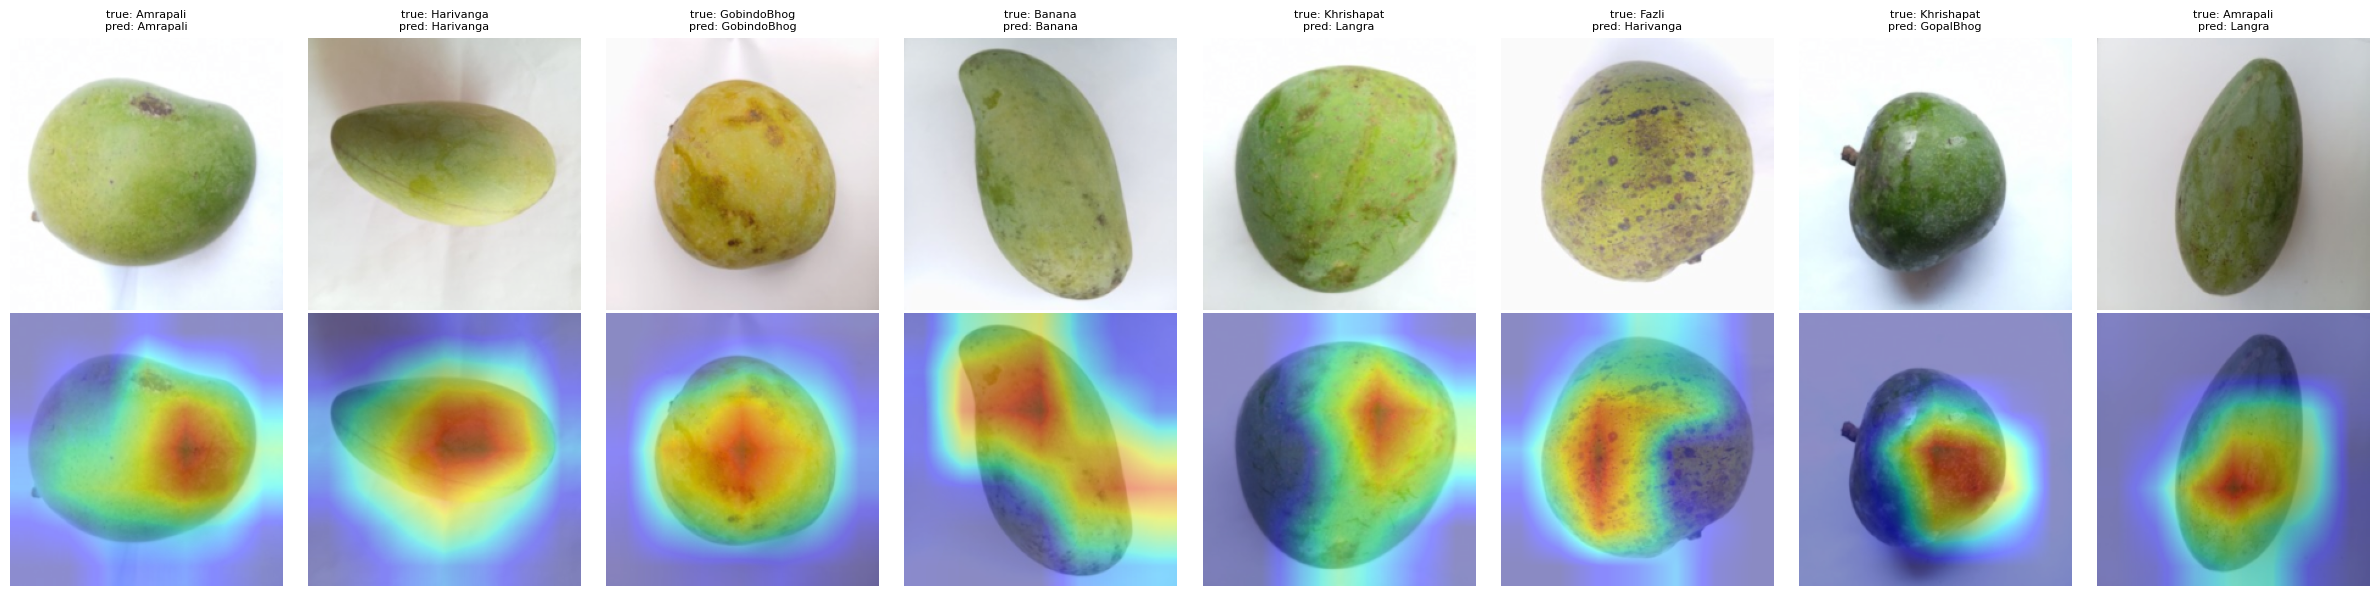

In [36]:
model = make_model("mobilenet", NC).to(device); model.load_state_dict(torch.load(OUT / "E6.pt")); model.eval()
acts, grads = {}, {}
layer = model.features[-1]
def fwd_hook(m, i, o):
    acts["a"] = o
    o.register_hook(lambda g: grads.__setitem__("g", g))   # tensor hook (safe with in-place ReLU6)
layer.register_forward_hook(fwd_hook)

def gradcam(x):
    x = x.unsqueeze(0).to(device).requires_grad_(True)
    out = model(x); cls = out.argmax(1).item()
    model.zero_grad(); out[0, cls].backward()
    w = grads["g"].mean((2, 3), keepdim=True)
    cam = F.relu((w * acts["a"]).sum(1, keepdim=True))
    cam = F.interpolate(cam, size=(IMG, IMG), mode="bilinear", align_corners=False)[0, 0].detach().cpu().numpy()
    return (cam - cam.min()) / (cam.max() + 1e-8), cls

pred = pd.read_csv(OUT / "E6_preds.csv")
ok = pred[pred.true == pred.pred].sample(4, random_state=1)
bad = pred[pred.true != pred.pred]; bad = bad.sample(min(4, len(bad)), random_state=1)
sel = pd.concat([ok, bad])
mean, std = np.array(MEAN)[:, None, None], np.array(STD)[:, None, None]
fig, axes = plt.subplots(2, len(sel), figsize=(3 * len(sel), 6))
for j, (_, r) in enumerate(sel.iterrows()):
    x = plain_tf(Image.open(r.path).convert("RGB")); cam, cls = gradcam(x)
    img = (x.numpy() * std + mean).transpose(1, 2, 0).clip(0, 1)
    axes[0, j].imshow(img); axes[0, j].axis("off")
    axes[0, j].set_title(f"true: {classes[int(r.true)]}\npred: {classes[cls]}", fontsize=8)
    axes[1, j].imshow(img); axes[1, j].imshow(cam, cmap="jet", alpha=0.45); axes[1, j].axis("off")
plt.tight_layout(); plt.savefig(OUT / "gradcam.png", dpi=150); plt.show()

## Done. Files in `/kaggle/working/outputs`
`main_results.csv`, `per_class_E3_vs_E6.csv`, `efficiency.csv`, `splits.csv`, confusion/curve/Grad-CAM PNGs, checkpoints and per-experiment JSON/CSV.
Download them from the notebook's **Output** tab after a Save & Run All.

In [39]:
!ls -lh /kaggle/working/results.zip

-rw-r--r-- 1 root root 2.3M Sep 20 07:56 /kaggle/working/results.zip


In [38]:
!cd /kaggle/working && zip -r results.zip outputs -x "outputs/*.pt"

  adding: outputs/ (stored 0%)
  adding: outputs/E5_preds.csv (deflated 85%)
  adding: outputs/per_class_E3_vs_E6.csv (deflated 49%)
  adding: outputs/E6_s2_result.json (deflated 71%)
  adding: outputs/E3_s1_preds.csv (deflated 85%)
  adding: outputs/E7_resnet18_preds.csv (deflated 84%)
  adding: outputs/training_curves.png (deflated 4%)
  adding: outputs/E7_resnet18_result.json (deflated 69%)
  adding: outputs/E8_focal_result.json (deflated 70%)
  adding: outputs/E3_s1_result.json (deflated 71%)
  adding: outputs/E3_s2_result.json (deflated 71%)
  adding: outputs/E1_result.json (deflated 70%)
  adding: outputs/E7_efficientnet_preds.csv (deflated 84%)
  adding: outputs/E6_result.json (deflated 70%)
  adding: outputs/E2_preds.csv (deflated 83%)
  adding: outputs/efficiency.csv (deflated 2%)
  adding: outputs/E3_s2_preds.csv (deflated 85%)
  adding: outputs/E8_focal_preds.csv (deflated 83%)
  adding: outputs/E6_s1_result.json (deflated 70%)
  adding: outputs/extension_results.csv (deflat